In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.svm import SVR
!pip install xgboost
from xgboost import XGBRegressor

!pip install mlxtend==0.22.0
from mlxtend.feature_selection import SequentialFeatureSelector

!pip install shap
import shap

import warnings
warnings.filterwarnings('ignore')

sns.set(style="darkgrid")
sns.set_palette("pastel")

In [4]:
data = pd.read_csv(r"C:\Users\thato\Downloads\all_seasons.csv")
data.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [6]:
data['draft_year'] = pd.to_numeric(data['draft_year'], errors='coerce').fillna(0).astype(int)
data['draft_round'] = pd.to_numeric(data['draft_round'], errors='coerce').fillna(0).astype(int)
data['draft_number'] = pd.to_numeric(data['draft_number'], errors='coerce').fillna(0).astype(int)
data.drop(['Unnamed: 0'],axis=1,inplace=True)

# Only dropped rows with nonsensical 0 entries
cols_to_check = [col for col in data.columns
                 if col not in ['reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct']]

data = data[~(data[cols_to_check] == 0).any(axis=1)]
data.reset_index(drop=True, inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        10178 non-null  object 
 1   team_abbreviation  10178 non-null  object 
 2   age                10178 non-null  float64
 3   player_height      10178 non-null  float64
 4   player_weight      10178 non-null  float64
 5   college            8597 non-null   object 
 6   country            10178 non-null  object 
 7   draft_year         10178 non-null  int32  
 8   draft_round        10178 non-null  int32  
 9   draft_number       10178 non-null  int32  
 10  gp                 10178 non-null  int64  
 11  pts                10178 non-null  float64
 12  reb                10178 non-null  float64
 13  ast                10178 non-null  float64
 14  net_rating         10178 non-null  float64
 15  oreb_pct           10178 non-null  float64
 16  dreb_pct           101

In [10]:
data.describe()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000
mean,27.056396,201.141845,100.976272,2003.997642,1.297210,21.634997,55.724700,9.202004,3.926901,2.008174,-1.386834,0.054580,0.143987,0.189360,0.523606,0.135373
std,4.476502,8.899086,12.331902,8.970544,0.501539,15.972866,22.450248,6.149121,2.517025,1.870998,7.911956,0.038878,0.057105,0.050467,0.071730,0.090516
min,18.000000,160.020000,60.327736,1963.000000,1.000000,1.000000,1.000000,0.100000,0.000000,0.000000,-82.900000,0.000000,0.000000,0.025000,0.101000,0.004000
25%,24.000000,195.580000,92.079176,1997.000000,1.000000,9.000000,41.000000,4.400000,2.100000,0.700000,-5.700000,0.022000,0.099000,0.154000,0.490000,0.070000
50%,26.000000,203.200000,100.243832,2004.000000,1.000000,19.000000,62.000000,7.800000,3.400000,1.400000,-0.900000,0.042000,0.135000,0.185000,0.529000,0.107000
75%,30.000000,208.280000,109.315672,2011.000000,2.000000,32.000000,75.000000,12.700000,5.200000,2.700000,3.300000,0.083000,0.182000,0.221000,0.564000,0.180000
max,44.000000,231.140000,155.582056,2022.000000,8.000000,165.000000,85.000000,36.100000,16.300000,11.700000,94.800000,0.300000,0.467000,0.414000,1.500000,1.000000


In [12]:
# Seperated data into numerical and categorical
obj_data=data.loc[:,['team_abbreviation','college','country','season']]  #Object data for encoding
players=data.loc[:,['player_name']]  #Player names to prepare for split
data.drop(columns=['player_name','team_abbreviation','college','country','season'],inplace=True) #Numerical data

X=data.drop(columns=['pts'])
y=data['pts']
X.head()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,22.0,193.04,94.800728,1996,2,42,64,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248
1,28.0,190.50,86.182480,1994,2,34,4,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043
2,26.0,203.20,103.418976,1993,1,12,41,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125
3,30.0,203.20,102.058200,1989,1,7,64,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125
4,23.0,213.36,119.748288,1995,1,22,52,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064


In [14]:
#Foward Selection on Numerical Data
sfs = SequentialFeatureSelector(
    LinearRegression(),
    k_features=(1, X.shape[1]),
    forward=True,
    floating=True,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)
sfs.fit(X, y)
selected_features = list(sfs.k_feature_names_)
print(selected_features)
X=X[selected_features]

['age', 'draft_round', 'draft_number', 'gp', 'reb', 'ast', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']


In [16]:
X.head()

,age,draft_round,draft_number,gp,reb,ast,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,22.0,2,42,64,1.5,2.4,0.042,0.071,0.169,0.487,0.248
1,28.0,2,34,4,1.3,0.3,0.030,0.111,0.174,0.497,0.043
2,26.0,1,12,41,6.4,1.9,0.106,0.185,0.175,0.512,0.125
3,30.0,1,7,64,2.8,1.7,0.027,0.111,0.206,0.527,0.125
4,23.0,1,22,52,1.7,0.3,0.102,0.169,0.195,0.500,0.064


In [18]:
obj_data.head()

,team_abbreviation,college,country,season
0,HOU,Louisiana State,USA,1996-97
1,WAS,Northwestern Oklahoma,USA,1996-97
2,VAN,North Carolina,USA,1996-97
3,LAL,Florida State,USA,1996-97
4,DEN,UCLA,USA,1996-97


In [20]:
#For Country and College kept only the entries that appeared more than 50 or 100 times respectively. Replaced other entries with "other"
country_counts = obj_data['country'].value_counts()
countries_to_keep = country_counts[country_counts > 50].index
obj_data['country'] = obj_data['country'].apply(lambda x: x if x in countries_to_keep else 'Other')

college_counts = obj_data['college'].value_counts(dropna=False)
colleges_to_keep = college_counts[college_counts > 100].index
obj_data['college'] = obj_data['college'].apply(lambda x: x if x in colleges_to_keep else 'other')
obj_data['college'] = obj_data['college'].fillna('other').apply(lambda x: x if x in colleges_to_keep else 'other')

In [22]:
obj_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   team_abbreviation  10178 non-null  object
 1   college            10178 non-null  object
 2   country            10178 non-null  object
 3   season             10178 non-null  object
dtypes: object(4)
memory usage: 318.2+ KB


In [24]:
#Encoded Categorical Data and dropped the "other" columns we created
obj_data=pd.get_dummies(obj_data,prefix='fet')
obj_data=obj_data.replace({False:0,True:1})
obj_data.drop(columns=['fet_other', 'fet_Other'],inplace=True)

In [26]:
obj_data.head()

,fet_ATL,fet_BKN,fet_BOS,fet_CHA,fet_CHH,fet_CHI,fet_CLE,fet_DAL,fet_DEN,fet_DET,...,fet_2013-14,fet_2014-15,fet_2015-16,fet_2016-17,fet_2017-18,fet_2018-19,fet_2019-20,fet_2020-21,fet_2021-22,fet_2022-23
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import statsmodels.api as sm
# Combined the 2 df together
X=pd.concat([X,obj_data],axis=1) # (10178,108)

x = X
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

# R2=0.921 , Adj. R2=0.920

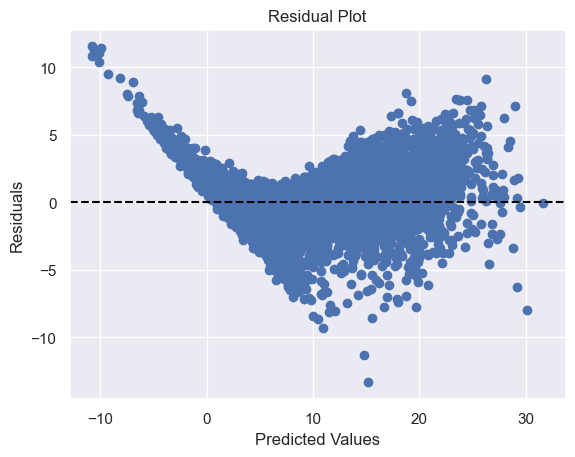

In [29]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
res=y-y_pred

plt.scatter(y_pred,res,color='b')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [34]:
X.shape

(10178, 68)

In [32]:
#Dropping features with p-val>0.05
p_values = model.pvalues

# list of features to remove
features_to_remove = []
for feature, p_value in p_values.items():
    if p_value > 0.05 and feature != 'const':
        features_to_remove.append(feature)

X = X.drop(columns=features_to_remove) # (10178,68)

In [ ]:
x = X
x = sm.add_constant(x)  # Use sm.add_constant directly
model = sm.OLS(y, x).fit()
model.summary()
# R2=0.921 , Adj. R2=0.920 (adj. R2 didnt change by dropping 40 fets)

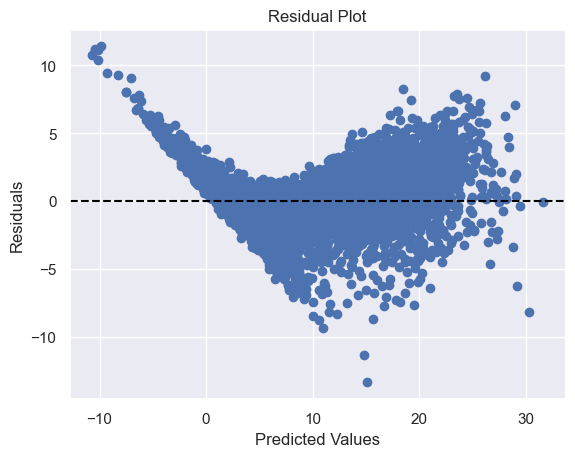

In [38]:
#Residual Plot
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
res=y-y_pred

plt.scatter(y_pred,res,color='b')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [40]:
#Scaling data
from sklearn.model_selection import GroupShuffleSplit

#scaler = StandardScaler()
#for col in X.columns:
    #X[col] = scaler.fit_transform(X[[col]])

# Split the data making sure players that appear multiple times are grouped together
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=162)
train_idx, test_idx = next(gss.split(X, y, groups=players))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=162)

X.head()

,age,draft_round,draft_number,gp,reb,ast,oreb_pct,dreb_pct,usg_pct,ts_pct,...,fet_2010-11,fet_2011-12,fet_2012-13,fet_2013-14,fet_2014-15,fet_2015-16,fet_2016-17,fet_2017-18,fet_2018-19,fet_2021-22
0,22.0,2,42,64,1.5,2.4,0.042,0.071,0.169,0.487,...,0,0,0,0,0,0,0,0,0,0
1,28.0,2,34,4,1.3,0.3,0.030,0.111,0.174,0.497,...,0,0,0,0,0,0,0,0,0,0
2,26.0,1,12,41,6.4,1.9,0.106,0.185,0.175,0.512,...,0,0,0,0,0,0,0,0,0,0
3,30.0,1,7,64,2.8,1.7,0.027,0.111,0.206,0.527,...,0,0,0,0,0,0,0,0,0,0
4,23.0,1,22,52,1.7,0.3,0.102,0.169,0.195,0.500,...,0,0,0,0,0,0,0,0,0,0


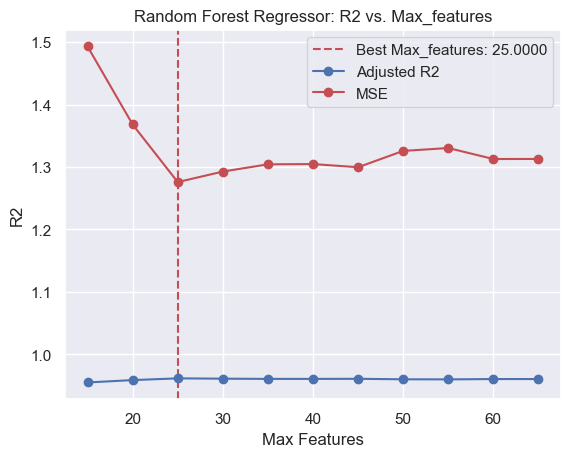

In [43]:
## Optimizing RandomForestRegressor max_features
fet_vals=range(15,70,5)
adj_r2_scores=[]
mse_scores=[]

for i in fet_vals:
  RF_car = RFR(max_features=i,
            random_state=0).fit(X_train, y_train)
  y_pred = RF_car.predict(X_test)
  r2=r2_score(y_test, y_pred)
  mse_scores.append(mean_squared_error(y_test, y_pred))
  adj_r2_scores.append(1-(((1-r2)*(len(X_test)-1))/(len(X_test)-X_test.shape[1]-1)))

best_K = fet_vals[np.argmax(adj_r2_scores)]

plt.axvline(best_K, color='r', linestyle='--', label=f'Best Max_features: {best_K:.4f}')
plt.plot(fet_vals, adj_r2_scores,marker='o', label='Adjusted R2',color='b')
plt.plot(fet_vals, mse_scores,marker='o', label='MSE',color='r')
plt.xlabel('Max Features')
plt.ylabel('R2')
plt.title('Random Forest Regressor: R2 vs. Max_features')
plt.legend()

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'n_estimators': [50,100,200,300],
    'max_depth': [None, 5,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2],
}


rf = RandomForestRegressor(max_features=25,random_state=162)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=15, scoring='r2',
                                   cv=3, n_jobs=-1, verbose=2, random_state=42)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

# Get the best model
best_rf_model = random_search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best score: 0.9558599060685556


In [47]:
# 10 Most important features for Random Forest Regressor
feature_imp = pd.DataFrame(
    {'importance': best_rf_model.feature_importances_},
    index=X_train.columns
)

top_10_features = feature_imp.sort_values(by='importance', ascending=False).head(10)
print(top_10_features)

              importance
usg_pct         0.378008
ast             0.213395
reb             0.190431
ts_pct          0.064085
gp              0.040818
ast_pct         0.037278
draft_number    0.022768
dreb_pct        0.019266
oreb_pct        0.015473
age             0.004918


In [49]:
#Optimizing ElasticNet
param_distributions = {
    'alpha': np.logspace(-5, 5, 100),
    'l1_ratio': np.arange(0, 1, 0.01)
}

elastic_net = ElasticNet()

random_search = RandomizedSearchCV(
    estimator=elastic_net,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

best_EN_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'l1_ratio': 0.99, 'alpha': 0.0006579332246575682}
Best score: 0.9148827774249501


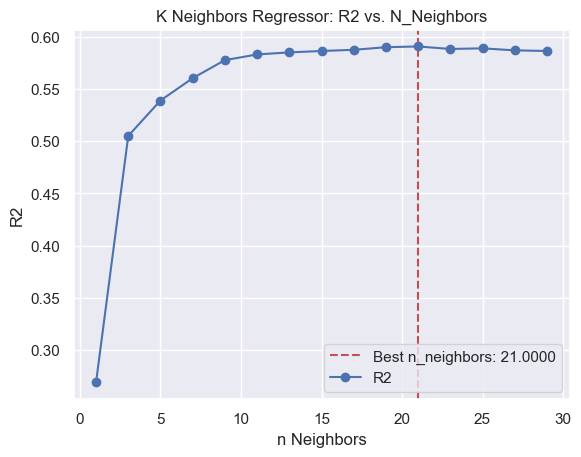

In [51]:
#Optimizing KNN Regressor n_neighbors
from sklearn.neighbors import KNeighborsRegressor
fet_vals=range(1,30,2)
r2_scores=[]
for i in fet_vals:
  knn_model = KNeighborsRegressor(n_neighbors=i).fit(X_train, y_train)
  y_pred = knn_model.predict(X_test)
  r2_scores.append(r2_score(y_test, y_pred))

best_K = fet_vals[np.argmax(r2_scores)]

plt.axvline(best_K, color='r', linestyle='--', label=f'Best n_neighbors: {best_K:.4f}')
plt.plot(fet_vals,r2_scores,marker='o', label='R2',color='b')
plt.xlabel('n Neighbors')
plt.ylabel('R2')
plt.title('K Neighbors Regressor: R2 vs. N_Neighbors')
plt.legend()

In [53]:
## Optimizing RandomForestRegressor max_features
xgb = XGBRegressor(objective='reg:squarederror', random_state=162)

param_dist = {
    'n_estimators': np.arange(50, 300, 25),
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0],
    'tree_method': ['auto', 'gpu_hist']
}


random_search = RandomizedSearchCV(xgb, param_dist, n_iter=50, cv=5, scoring='r2', n_jobs=-1)
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best R^2 score: {random_search.best_score_}")

Best parameters: {'tree_method': 'auto', 'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 250, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
Best R^2 score: 0.981531452962173


 99%|===================| 2180/2206 [00:21<00:00]        

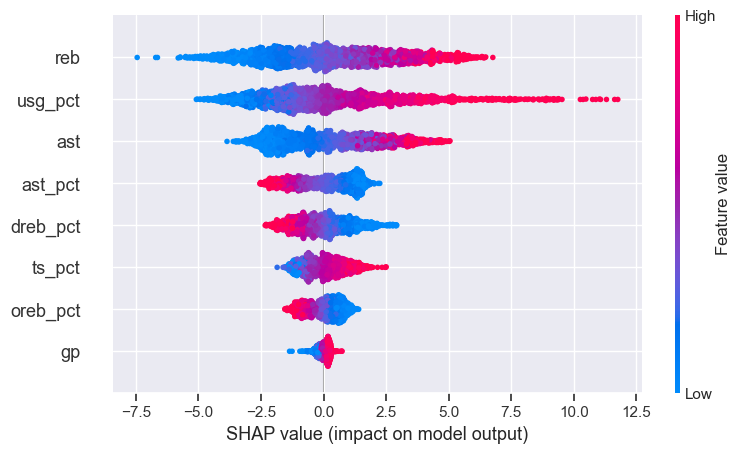

In [75]:
model = XGBRegressor(n_estimators=250,tree_method='auto',subsample=0.8,reg_lambda=1,reg_alpha=0,min_child_weight=5,max_depth=5,learning_rate=0.05,gamma=0,colsample_bytree=0.8)
model.fit(X_train, y_train)

# Explain the model using SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, max_display=8)

In [55]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'ccp_alpha': np.arange(0.0, 0.05, 0.0001)  # Explore values between 0 and 0.1
}

# Create a DecisionTreeRegressor object
tree = DTR(random_state=162)  # Set random_state for reproducibility

# Create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='r2',  
    cv=5,          
    n_jobs=-1       
)

grid_search.fit(X_train, y_train)

print("Best ccp_alpha:", grid_search.best_params_['ccp_alpha'])
print("Best R-squared score:", grid_search.best_score_)

# Get the best DecisionTreeRegressor model
best_tree = grid_search.best_estimator_

Best ccp_alpha: 0.0015
Best R-squared score: 0.9052423357204662


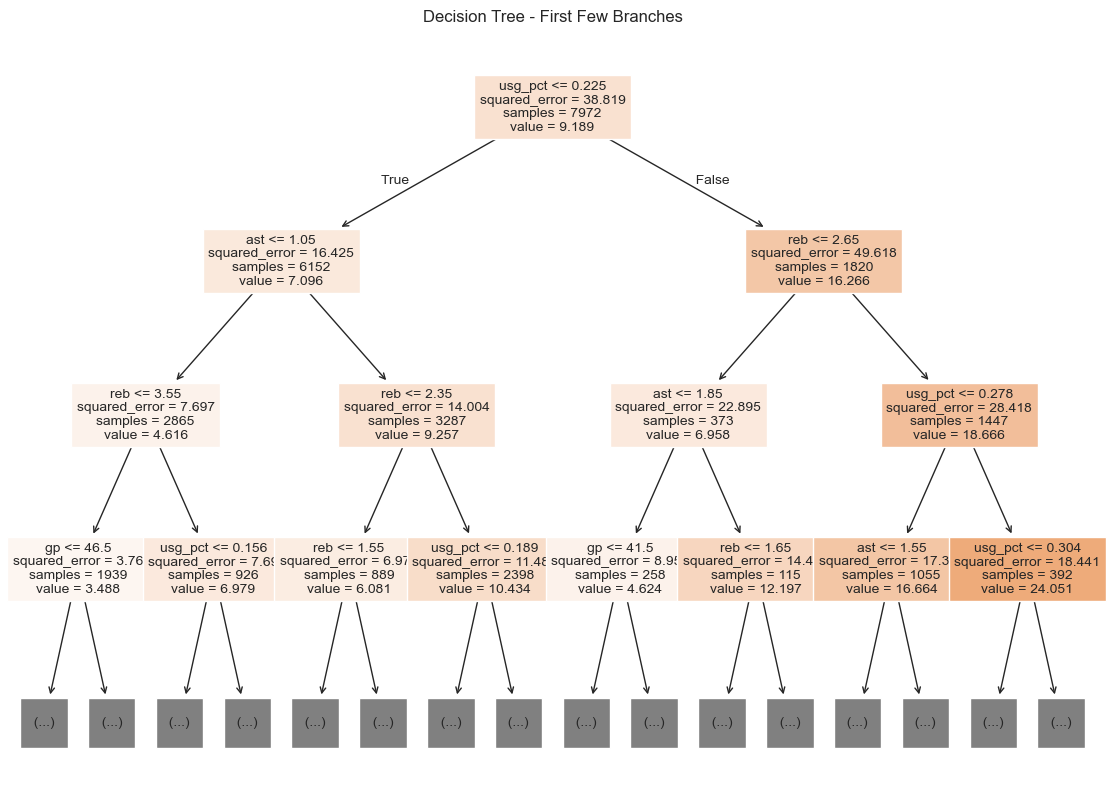

In [67]:
from sklearn.tree import plot_tree
plt.figure(figsize=(14, 10))  # Adjust figure size as needed
plot_tree(
    best_tree,
    max_depth=3,  # Display only the first 3 levels of the tree
    feature_names=X_train.columns,  # Set feature names for better readability
    filled=True,  # Fill nodes with colors based on class
    fontsize=10   # Adjust fontsize for better visibility
)
plt.title("Decision Tree - First Few Branches")
plt.show()

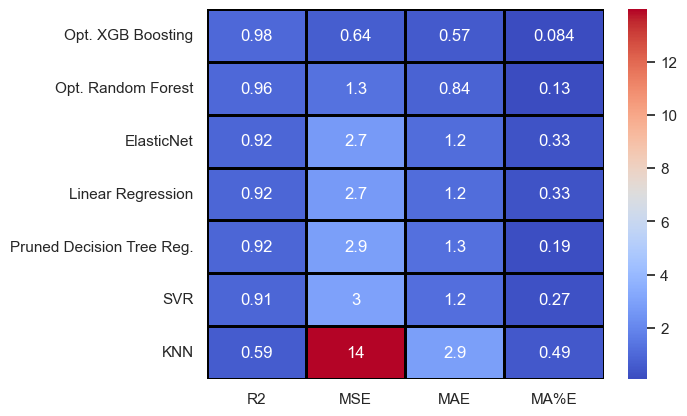

In [59]:
# Fit all Optimized and other models and produced some scores (Removed Lasso and Ridge since they have the same socres as the base Linear model)
model_dic = {
    "Linear Regression": LinearRegression(),
    "ElasticNet": best_EN_model,
    "Pruned Decision Tree Reg.": best_tree,
    "Opt. Random Forest": best_rf_model,
    "SVR": SVR(kernel='linear'),
    "Opt. XGB Boosting": XGBRegressor(n_estimators=250,tree_method='auto',subsample=0.8,reg_lambda=1,reg_alpha=0,min_child_weight=5,max_depth=5,learning_rate=0.05,gamma=0,colsample_bytree=0.8),
    "KNN": KNeighborsRegressor(n_neighbors=21),
}

metric_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    metric_dic[i]={'R2':r2_score(y_test,y_pred),
                "MSE"  :mean_squared_error(y_test,y_pred),
                "MAE"  :mean_absolute_error(y_test,y_pred),
                "MA%E"  :mean_absolute_percentage_error(y_test, y_pred)}

metric_dic=pd.DataFrame(metric_dic)
metric_dic_transposed = metric_dic.T
metric_dic_sorted = metric_dic_transposed.sort_values(by=['R2'],ascending=False)

sns.heatmap(metric_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()

Percentage of points with residuals less than 2: 97.60%


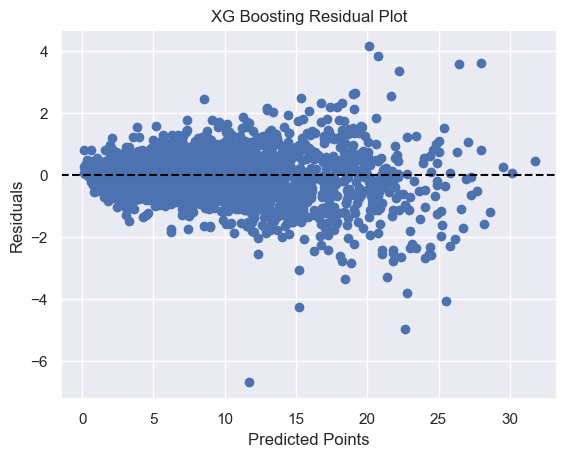

In [61]:
#Residual Plot for best performing model
xgb= XGBRegressor(n_estimators=275,tree_method='auto',subsample=1.0,reg_lambda=0.1,reg_alpha=0.1,min_child_weight=5,max_depth=5,learning_rate=0.1,gamma=0,colsample_bytree=0.8)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
res=y_test-y_pred

percentage_less_than_2 = (np.abs(res) < 2).mean() * 100

# Print the percentage
print(f"Percentage of points with residuals less than 2: {percentage_less_than_2:.2f}%")

plt.scatter(y_pred,res,color='b')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Points')
plt.ylabel('Residuals')
plt.title('XG Boosting Residual Plot')
plt.show()

Percentage of points with residuals less than 2: 84.27%


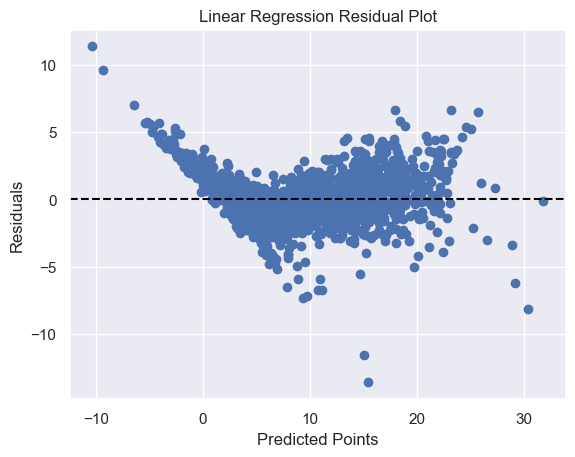

In [63]:
lr= LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
res=y_test-y_pred

percentage_less_than_2 = (np.abs(res) < 2).mean() * 100

# Print the percentage
print(f"Percentage of points with residuals less than 2: {percentage_less_than_2:.2f}%")

plt.scatter(y_pred,res,color='b')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Points')
plt.ylabel('Residuals')
plt.title('Linear Regression Residual Plot')
plt.show()

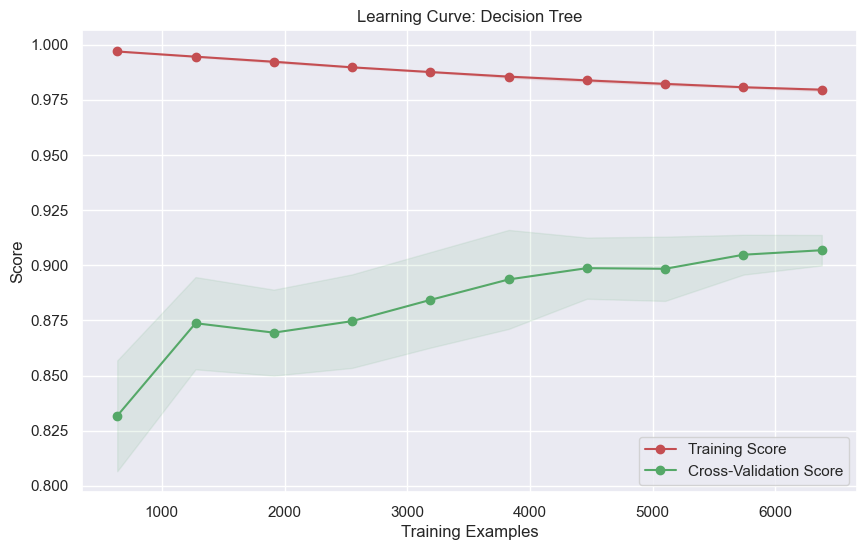

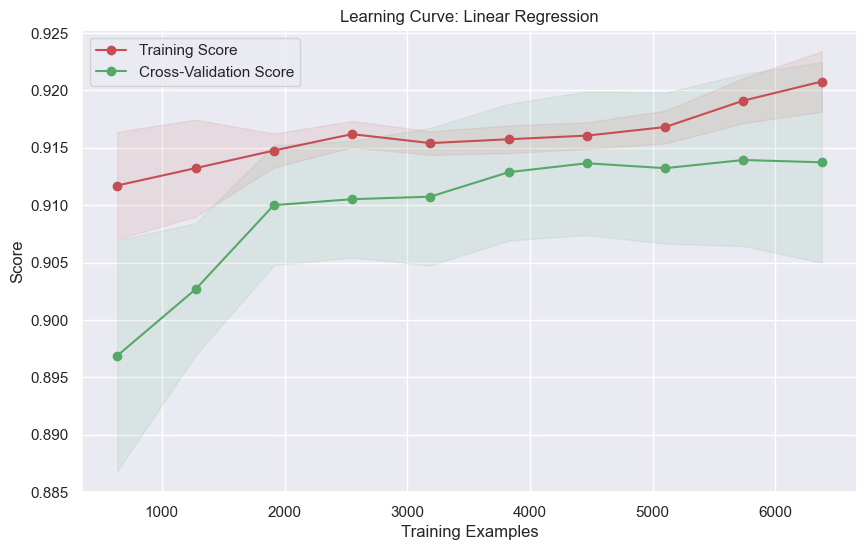

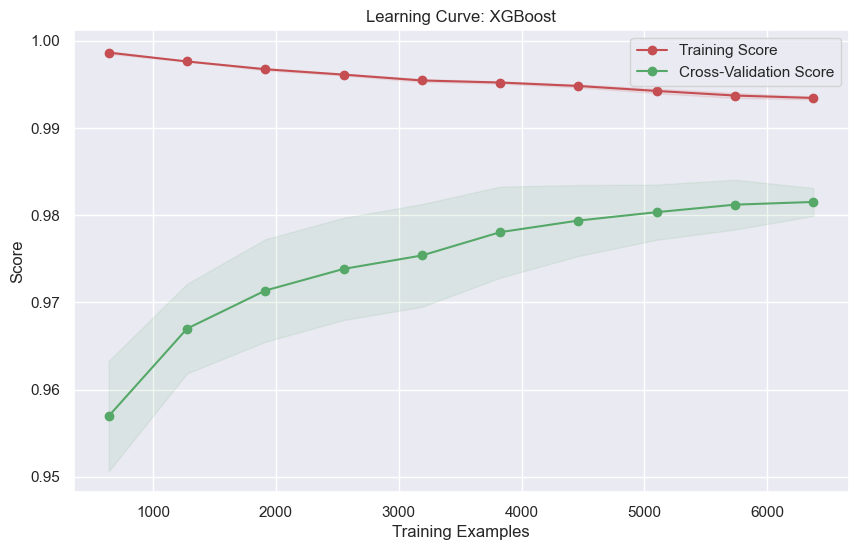

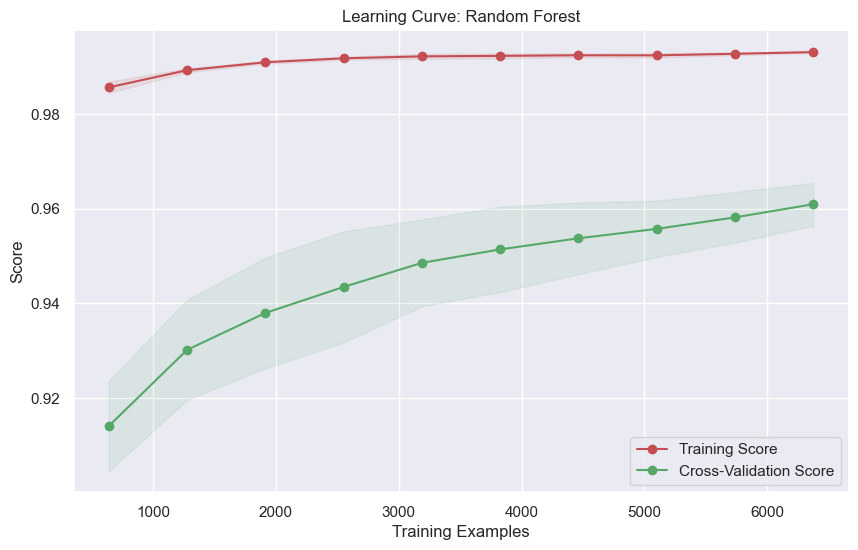

In [111]:
lr=LinearRegression()
xgboost_model = XGBRegressor(n_estimators=250,tree_method='auto',subsample=0.8,reg_lambda=1,reg_alpha=0,min_child_weight=5,max_depth=5,learning_rate=0.05,gamma=0,colsample_bytree=0.8)

def plot_learning_curve(estimator, X, y, title, cv=5, scoring=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("Score")


    plt.fill_between(
        train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, 
        alpha=0.1, color="r"
    )
    plt.fill_between(
        train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, 
        alpha=0.1, color="g"
    )

    # Plot mean learning curves
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")

    plt.legend(loc="best")
    plt.show()

plot_learning_curve(best_tree, X_train, y_train, "Learning Curve: Decision Tree", cv=5, scoring="r2")
plot_learning_curve(lr, X_train, y_train, "Learning Curve: Linear Regression", cv=5, scoring="r2")
plot_learning_curve(xgboost_model, X_train, y_train, "Learning Curve: XGBoost", cv=5, scoring="r2")
plot_learning_curve(best_rf_model, X_train, y_train, "Learning Curve: Random Forest", cv=5, scoring="r2")


In [52]:
LX=X.iloc[:,:11]
LX

,age,draft_round,draft_number,gp,reb,ast,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,22.0,2,42,64,1.5,2.4,0.042,0.071,0.169,0.487,0.248
1,28.0,2,34,4,1.3,0.3,0.030,0.111,0.174,0.497,0.043
2,26.0,1,12,41,6.4,1.9,0.106,0.185,0.175,0.512,0.125
3,30.0,1,7,64,2.8,1.7,0.027,0.111,0.206,0.527,0.125
4,23.0,1,22,52,1.7,0.3,0.102,0.169,0.195,0.500,0.064
...,...,...,...,...,...,...,...,...,...,...,...
10173,31.0,2,33,74,2.2,1.4,0.016,0.089,0.141,0.621,0.091
10174,23.0,2,41,9,0.4,0.3,0.000,0.068,0.115,0.321,0.083
10175,29.0,1,3,66,10.2,4.2,0.057,0.243,0.370,0.655,0.233
10176,25.0,1,19,71,6.5,1.2,0.035,0.180,0.168,0.593,0.052


In [54]:
vif_data = pd.DataFrame()
vif_data["Feature"] = LX.columns
vif_data["VIF"] = [variance_inflation_factor(LX.values, i) for i in range(LX.shape[1])]

# Print VIF
print(vif_data)

         Feature        VIF
0            age  28.431026
1    draft_round  28.085017
2   draft_number  11.645099
3             gp  10.417615
4            reb  12.337239
5            ast  13.095879
6       oreb_pct   6.648104
7       dreb_pct  21.881592
8        usg_pct  17.740605
9         ts_pct  41.968242
10       ast_pct  16.572782


In [56]:
LX.drop(columns=['age','draft_round','ts_pct','dreb_pct','ast_pct'],inplace=True)
LX.head()
        

,draft_number,gp,reb,ast,oreb_pct,usg_pct
0,42,64,1.5,2.4,0.042,0.169
1,34,4,1.3,0.3,0.030,0.174
2,12,41,6.4,1.9,0.106,0.175
3,7,64,2.8,1.7,0.027,0.206
4,22,52,1.7,0.3,0.102,0.195


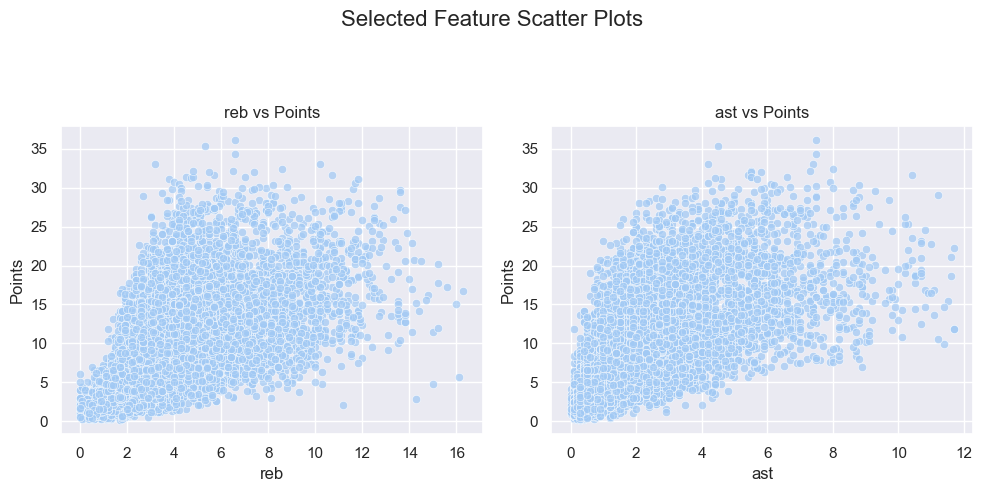

In [58]:
def plot_selected_scatter(LX, y, columns, title="Selected Feature Scatter Plots"):
    plt.figure(figsize=(10, 5))  # Set figure size
    plt.suptitle(title, fontsize=16)
    
    for i, feature in enumerate(columns):
        plt.subplot(1, len(columns), i + 1)
        sns.scatterplot(x=LX[feature], y=y, alpha=0.7)
        plt.title(f"{feature} vs Points", fontsize=12)
        plt.xlabel(feature)
        plt.ylabel("Points")

    plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust layout to fit title
    plt.show()

# Example usage
columns_to_plot = ['reb', 'ast']
plot_selected_scatter(LX, y, columns_to_plot)

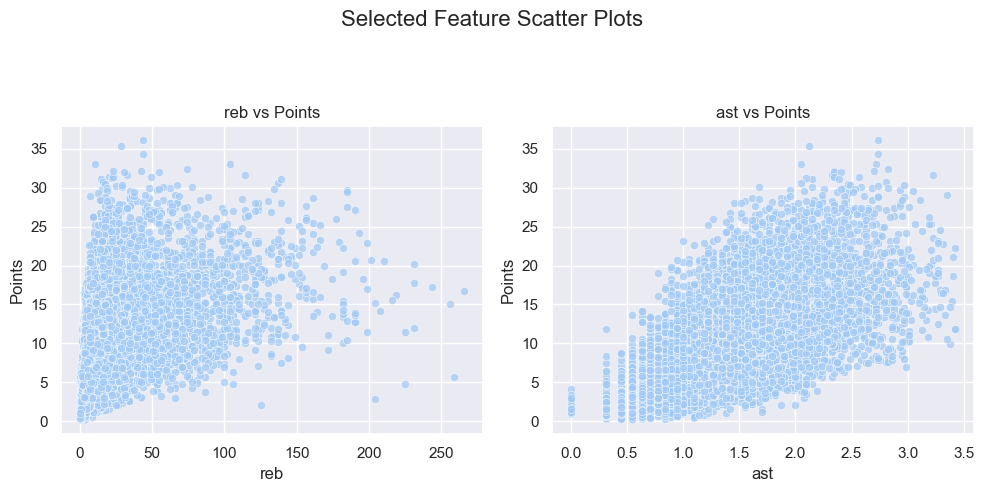

In [60]:
LX['reb']=(LX['reb'])**2
LX['ast']=(LX['ast'])**0.5

plot_selected_scatter(LX, y, columns_to_plot)

In [62]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=162)
train_idx, test_idx = next(gss.split(LX, y, groups=players))

LX_train, LX_test = LX.iloc[train_idx], LX.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

Percentage of points with residuals less than 2: 61.60%
0.8191921132541763
6.1747420445001575
1.9106098926579713
0.4120072315170209


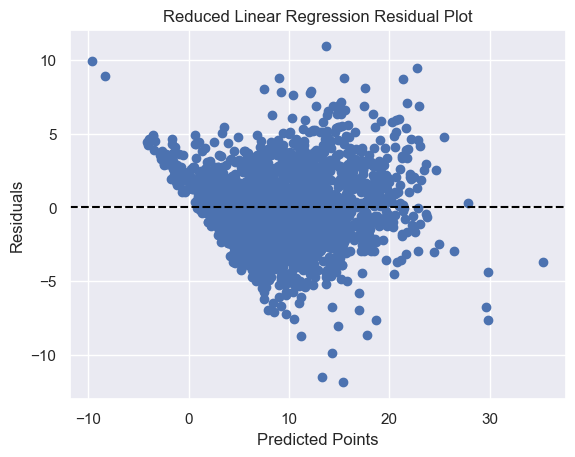

In [64]:
lr= LinearRegression()
lr.fit(LX_train, y_train)
y_pred = lr.predict(LX_test)
res=y_test-y_pred

percentage_less_than_2 = (np.abs(res) < 2).mean() * 100

# Print the percentage
print(f"Percentage of points with residuals less than 2: {percentage_less_than_2:.2f}%")
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_absolute_percentage_error(y_test,y_pred))

plt.scatter(y_pred,res,color='b')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Points')
plt.ylabel('Residuals')
plt.title('Reduced Linear Regression Residual Plot')
plt.show()

In [66]:
print("Coefficients:", lr.coef_)

# Print the intercept
print("Intercept:", lr.intercept_)

Coefficients: [-2.35335191e-02  5.17623763e-02  6.08681193e-02  3.18175077e+00
 -1.19060981e+01  5.72704132e+01]
Intercept: -8.77150659462712


In [74]:
from scipy.stats import t

def add_intercept(X):
    intercept = np.ones((X.shape[0], 1))  # Column of 1s
    return np.hstack((intercept, X))

def prediction_interval(X_train, y_train, x_new, confidence=0.95):

    X_train = add_intercept(np.array(X_train))
    y_train = np.array(y_train).reshape(-1, 1)  
    
    # Step 2: Calculate beta coefficients
    beta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train  # OLS solution for beta
    
    # Step 3: Add intercept to x_new
    x_new = np.array([1] + x_new).reshape(1, -1)  # Ensure row vector with intercept
    y_pred = x_new @ beta  # Predicted value for x_new
    
    # Step 4: Calculate residual variance (sigma^2)
    residuals = y_train - X_train @ beta
    n, p = X_train.shape  # Number of observations and parameters
    sigma_squared = (residuals.T @ residuals) / (n - p)
    
    # Step 5: Compute variance of prediction
    var_pred = float(sigma_squared * (1 + x_new @ np.linalg.inv(X_train.T @ X_train) @ x_new.T))
    
    # Step 6: Get t-critical value for confidence level
    t_critical = t.ppf((1 + confidence) / 2, df=n - p)  # Two-tailed t-value
    
    # Step 7: Calculate prediction interval
    margin_of_error = t_critical * np.sqrt(var_pred)
    lower_bound = y_pred - margin_of_error
    upper_bound = y_pred + margin_of_error
    
    return float(y_pred), float(lower_bound), float(upper_bound)


y_pred, lower, upper = prediction_interval(LX_train, y_train, x_new=[1,71,112.36,1.97484,0.074,0.312])

print(f"Predicted value: {y_pred}")
print(f"Prediction interval: [{lower}, {upper}]")


Predicted value: 24.989996817317838
Prediction interval: [19.820738654337767, 30.15925498029791]
